# 05 · Evaluación de los modelos

**Proyecto:** Identificación de hogares en situación de pobreza monetaria mediante aprendizaje automático (ENAHO 2025).

Este cuaderno corresponde a la **Fase 5 de CRISP-DM: Evaluación** y responde a los objetivos específicos:

- **OE4:** evaluar experimentalmente el desempeño de los modelos con métricas apropiadas;
- **OE5:** comparar los resultados y determinar el modelo con mejor desempeño bajo las condiciones experimentales establecidas.

**Entrada:** los modelos del cuaderno 04, el conjunto de prueba y el dataset de 2024. **Salida:** las tablas y figuras de la evaluación (`results/`) y el modelo final (`models/modelo_final.joblib`), que es el que usa el prototipo.

Contenido:

1. evaluación de todos los modelos en el **conjunto de prueba** (usado aquí por primera y única vez);
2. matriz de confusión, en términos de hogares;
3. curvas ROC;
4. análisis del umbral de decisión;
5. generalización: entrenamiento, validación cruzada y prueba;
6. **validación temporal (E6):** entrenar con la ENAHO 2024 y evaluar con los hogares nuevos de 2025;
7. interpretabilidad: ¿por qué el modelo decide lo que decide?;
8. análisis de sesgo por área, dominio y sexo del jefe(a) del hogar;
9. evaluación del modelo como artefacto: tiempo de respuesta y tamaño;
10. selección final y guardado del modelo para el prototipo.

In [1]:
# ==========================================================
# CONFIGURACIÓN DEL ENTORNO (funciona en Google Colab y en local)
# ==========================================================
# En Colab, la primera vez conviene instalar las versiones del proyecto y reiniciar la sesión:
# !pip install -r /content/drive/MyDrive/proyecto-pobreza-ia/requirements.txt
import os
import sys

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    # En Colab: montamos Google Drive y nos ubicamos en la carpeta del proyecto
    from google.colab import drive
    drive.mount("/content/drive")
    RUTA_PROYECTO = "/content/drive/MyDrive/proyecto-pobreza-ia"  # ajustar si el proyecto está en otra carpeta
    os.chdir(RUTA_PROYECTO)
elif os.path.basename(os.getcwd()) == "notebooks":
    # En local: si el notebook se abre desde la carpeta notebooks/, subimos a la raíz
    os.chdir("..")

# Comprobamos que estamos en la raíz del proyecto y permitimos importar su código (carpeta src/)
assert os.path.isdir("src"), "No se encuentra la carpeta src/: revisa RUTA_PROYECTO"
sys.path.insert(0, os.getcwd())
print("Entorno:", "Google Colab" if EN_COLAB else "local", "| Carpeta del proyecto:", os.path.basename(os.getcwd()))

Entorno: local | Carpeta del proyecto: proyecto-pobreza-ia


In [2]:
# Librerías
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix, roc_curve, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Código propio del proyecto (carpeta src/)
from src.config import SEMILLA, RUTA_HOGARES, RUTA_PARTICION, RUTA_PANEL_2025, CARPETA_MODELOS
from src.features.construir import VARIABLES_PREDICTORAS, VARIABLE_OBJETIVO, CLAVES_HOGAR, ETIQUETAS
from src.preprocessing.particion import aplicar_particion
from src.models.modelos import crear_pipeline, regla_rural
from src.evaluation.metricas import calcular_metricas
from src.evaluation.interpretacion import (
    nombre_legible, variable_original, calcular_referencia, puntaje_referencia, explicar_hogar, resumir_por_grupo,
)
from src.visualizacion import (
    aplicar_estilo, guardar_figura, AZUL, NARANJA, VERDE_AGUA, AMARILLO, TEXTO_SECUNDARIO,
)

aplicar_estilo()
os.makedirs("results/tablas", exist_ok=True)

hogares = pd.read_csv(RUTA_HOGARES[2025])
entrenamiento, prueba = aplicar_particion(hogares, RUTA_PARTICION)
X_entrenamiento, y_entrenamiento = entrenamiento[VARIABLES_PREDICTORAS], entrenamiento[VARIABLE_OBJETIVO]
X_prueba, y_prueba = prueba[VARIABLES_PREDICTORAS], prueba[VARIABLE_OBJETIVO]
print("Prueba:", X_prueba.shape, "| hogares pobres:", int(y_prueba.sum()), "| no pobres:", int((y_prueba == 0).sum()))

# Modelos entrenados en el cuaderno 04
archivos = {
    "E1 Regresión logística (defecto)": "e1_regresion_logistica_defecto.joblib",
    "E2 Regresión logística": "e2_regresion_logistica.joblib",
    "E3 Árbol de decisión": "e3_arbol_decision.joblib",
    "E4 KNN": "e4_knn.joblib",
    "E5 Random Forest": "e5_random_forest.joblib",
}
modelos = {nombre: joblib.load(os.path.join(CARPETA_MODELOS, archivo)) for nombre, archivo in archivos.items()}
print("Modelos cargados:", list(modelos))

Prueba: (6741, 36) | hogares pobres: 1221 | no pobres: 5520
Modelos cargados: ['E1 Regresión logística (defecto)', 'E2 Regresión logística', 'E3 Árbol de decisión', 'E4 KNN', 'E5 Random Forest']


## 1. Evaluación en el conjunto de prueba

Los 6 741 hogares de prueba **no se usaron en ninguna decisión anterior**: ni en la preparación, ni en la elección de hiperparámetros, ni en la selección preliminar del modelo. Por eso, estas métricas son la estimación más honesta del desempeño con hogares nuevos. Todos los modelos usan el umbral de 0,5 definido de antemano.

In [3]:
probabilidades = {nombre: modelo.predict_proba(X_prueba)[:, 1] for nombre, modelo in modelos.items()}

resultados_prueba = {"E0 Regla 'rural = pobre'": calcular_metricas(y_prueba, regla_rural(X_prueba))}
for nombre, prob in probabilidades.items():
    resultados_prueba[nombre] = calcular_metricas(y_prueba, (prob >= 0.5).astype(int), prob)

tabla_prueba = pd.DataFrame(resultados_prueba).T[["f1", "precision", "recall", "roc_auc", "accuracy"]]

# Comparación con la validación cruzada del cuaderno 04
cv = pd.read_csv("results/tablas/04_comparacion_validacion_cruzada.csv", index_col=0)
tabla_prueba["f1_validacion_cruzada"] = cv["f1_media"]
tabla_prueba = tabla_prueba.sort_values("f1", ascending=False)
tabla_prueba.to_csv("results/tablas/05_metricas_prueba.csv")
tabla_prueba.round(3)

,f1,precision,recall,roc_auc,accuracy,f1_validacion_cruzada
E5 Random Forest,0.549,0.455,0.691,0.849,0.794,0.552
E2 Regresión logística,0.544,0.413,0.798,0.853,0.758,0.552
E3 Árbol de decisión,0.495,0.367,0.759,0.808,0.719,0.500
E1 Regresión logística (defecto),0.416,0.601,0.319,0.851,0.838,0.443
E4 KNN,0.406,0.466,0.360,0.724,0.809,0.397
E0 Regla 'rural = pobre',0.334,0.255,0.484,NaN,0.651,0.347


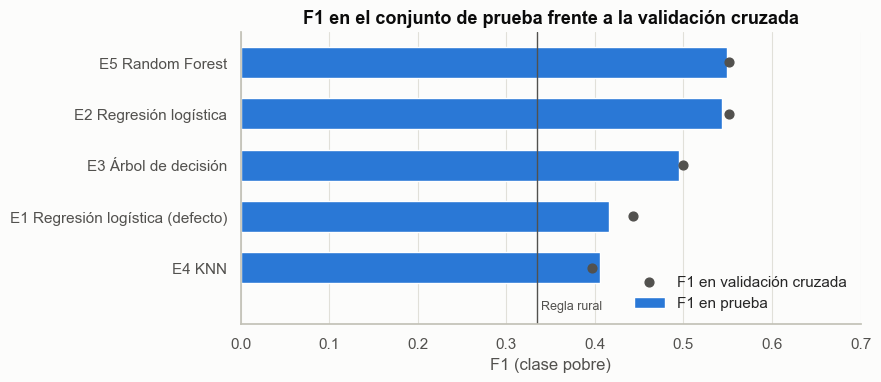

In [4]:
orden = tabla_prueba.drop(index="E0 Regla 'rural = pobre'").sort_values("f1")
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(orden.index, orden["f1"], color=AZUL, height=0.6, label="F1 en prueba")
ax.scatter(orden["f1_validacion_cruzada"], orden.index, color=TEXTO_SECUNDARIO, s=40, zorder=3, label="F1 en validación cruzada")
ax.axvline(tabla_prueba.loc["E0 Regla 'rural = pobre'", "f1"], color=TEXTO_SECUNDARIO, linewidth=1)
ax.set_ylim(-1.1, len(orden) - 0.4)
ax.text(tabla_prueba.loc["E0 Regla 'rural = pobre'", "f1"] + 0.005, -0.8, "Regla rural", color=TEXTO_SECUNDARIO, fontsize=9)
ax.set_xlabel("F1 (clase pobre)")
ax.set_xlim(0, 0.7)
ax.set_title("F1 en el conjunto de prueba frente a la validación cruzada")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
guardar_figura("05_f1_prueba_vs_cv")
plt.show()

### Interpretación

- En el conjunto de prueba se mantiene **el mismo orden** que en la validación cruzada. Random Forest (F1 = 0,549) y la regresión logística ajustada (F1 = 0,544) siguen empatados en la cima, seguidos del árbol (0,495), la regresión logística sin ajustar (0,416), KNN (0,406) y la regla rural (0,334).
- **Los valores de prueba son muy cercanos a los de validación cruzada** (regresión logística: 0,544 frente a 0,552; Random Forest: 0,549 frente a 0,552). Las decisiones del cuaderno 04 no estaban sobreajustadas a las particiones de validación, y el desempeño se sostiene con hogares nunca vistos.
- La diferencia entre Random Forest y la regresión logística en prueba (0,005) sigue siendo menor que la desviación estándar observada entre particiones (0,010 a 0,014), así que **se mantiene el empate práctico**.

## 2. Matriz de confusión: ¿qué significan los errores en hogares?

Comparamos el modelo seleccionado (regresión logística, E2) con la regla rural (E0) sobre los mismos 6 741 hogares.

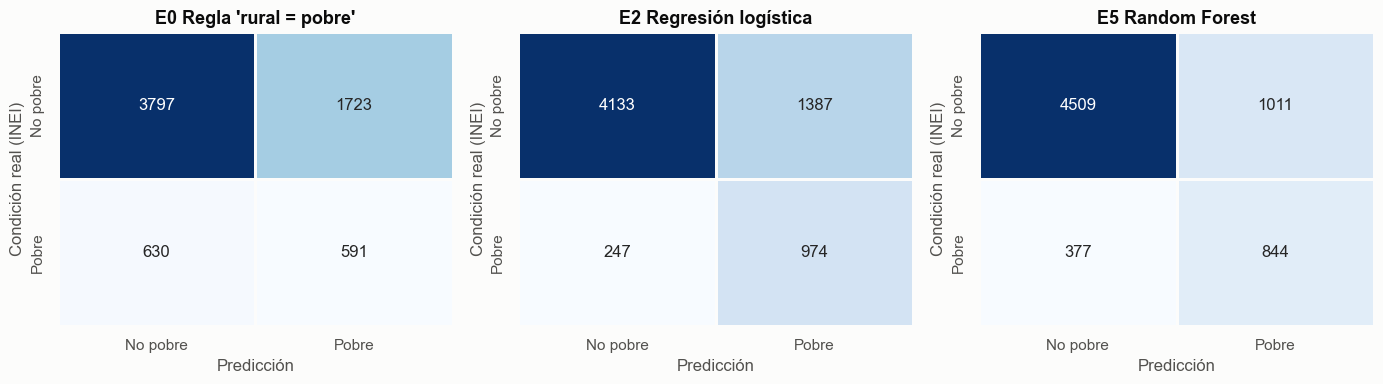

,pobres_detectados (VP),pobres_excluidos (FN),no_pobres_incluidos (FP),no_pobres_bien_descartados (VN)
E0 Regla 'rural = pobre',591,630,1723,3797
E2 Regresión logística,974,247,1387,4133
E5 Random Forest,844,377,1011,4509


In [5]:
matrices = {
    "E0 Regla 'rural = pobre'": confusion_matrix(y_prueba, regla_rural(X_prueba)),
    "E2 Regresión logística": confusion_matrix(y_prueba, (probabilidades["E2 Regresión logística"] >= 0.5).astype(int)),
    "E5 Random Forest": confusion_matrix(y_prueba, (probabilidades["E5 Random Forest"] >= 0.5).astype(int)),
}

fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nombre, matriz) in zip(ejes, matrices.items()):
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=2, linecolor="#fcfcfb",
                xticklabels=["No pobre", "Pobre"], yticklabels=["No pobre", "Pobre"], ax=ax, annot_kws={"size": 12})
    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Condición real (INEI)")
fig.tight_layout()
guardar_figura("05_matrices_confusion")
plt.show()

resumen_errores = pd.DataFrame({
    nombre: {
        "pobres_detectados (VP)": m[1, 1],
        "pobres_excluidos (FN)": m[1, 0],
        "no_pobres_incluidos (FP)": m[0, 1],
        "no_pobres_bien_descartados (VN)": m[0, 0],
    } for nombre, m in matrices.items()
}).T
resumen_errores

### Interpretación en términos de hogares

De los **1 221 hogares pobres** del conjunto de prueba:

| | Regla rural | Regresión logística | Diferencia |
|---|---|---|---|
| Hogares pobres **detectados** | 591 | **974** | **+383** |
| Hogares pobres **excluidos** (error de exclusión) | 630 | **247** | **−383** |
| Hogares no pobres **incluidos** (error de inclusión) | 1 723 | **1 387** | **−336** |

**El modelo es mejor que la regla en los dos tipos de error a la vez:** detecta 383 hogares pobres más y, al mismo tiempo, incluye por error a 336 hogares no pobres menos. No es solo un cambio del punto de equilibrio: es una mejora real. Esta es la evidencia más directa de que **la IA aporta valor** frente a la focalización geográfica simple.

Frente a Random Forest, la regresión logística detecta **130 hogares pobres más** (974 frente a 844), pero incluye **376 hogares no pobres más** (1 387 frente a 1 011). Es la diferencia de equilibrio ya vista en el cuaderno 04: la regresión logística prioriza **no dejar pobres fuera**.

El error que persiste es importante: el modelo marca como pobres a 1 387 hogares no pobres. De cada 10 hogares que prioriza, unos 4 son pobres según el INEI. Esto refleja un **límite de la información observable**: hay hogares con características de vivienda y bienes parecidas y distinta condición de pobreza monetaria.

## 3. Curvas ROC

La curva ROC muestra, para todos los umbrales posibles, la proporción de pobres detectados (tasa de verdaderos positivos) frente a la proporción de no pobres incluidos por error (tasa de falsos positivos). El área bajo la curva (AUC) resume la capacidad del modelo de **ordenar** a los hogares por riesgo (cuaderno 11 del curso).

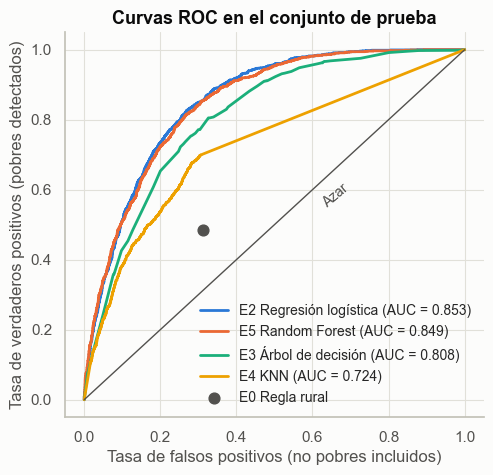

In [6]:
colores = {"E2 Regresión logística": AZUL, "E5 Random Forest": NARANJA, "E3 Árbol de decisión": VERDE_AGUA, "E4 KNN": AMARILLO}

fig, ax = plt.subplots(figsize=(5.4, 5))
for nombre, color in colores.items():
    fpr, tpr, _ = roc_curve(y_prueba, probabilidades[nombre])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{nombre} (AUC = {tabla_prueba.loc[nombre, 'roc_auc']:.3f})")

# La regla rural es un único punto (no tiene probabilidades)
m = matrices["E0 Regla 'rural = pobre'"]
ax.scatter(m[0, 1] / m[0].sum(), m[1, 1] / m[1].sum(), color=TEXTO_SECUNDARIO, s=60, zorder=3, label="E0 Regla rural")
ax.plot([0, 1], [0, 1], color=TEXTO_SECUNDARIO, linewidth=1)
ax.text(0.62, 0.55, "Azar", color=TEXTO_SECUNDARIO, fontsize=10, rotation=40)
ax.set_xlabel("Tasa de falsos positivos (no pobres incluidos)")
ax.set_ylabel("Tasa de verdaderos positivos (pobres detectados)")
ax.set_title("Curvas ROC en el conjunto de prueba")
ax.legend(loc="lower right", fontsize=10)
guardar_figura("05_curvas_roc")
plt.show()

### Interpretación

- La regresión logística (AUC = 0,853) y Random Forest (0,849) tienen curvas casi superpuestas, clara evidencia de su empate. El árbol (0,808) y sobre todo KNN (0,724) quedan por debajo en todos los umbrales.
- **La regla rural queda por debajo de las curvas de los modelos:** para su misma tasa de falsos positivos, cualquiera de los modelos detecta muchos más hogares pobres. La regla es un punto ineficiente.
- Un AUC de 0,853 significa que, si se toma al azar un hogar pobre y uno no pobre, el modelo asigna mayor probabilidad al pobre en el 85 % de los casos.

## 4. Análisis del umbral de decisión

Con un umbral de 0,5, el modelo marca como pobre a todo hogar con probabilidad ≥ 0,5. Mover el umbral cambia el equilibrio entre los dos errores (cuaderno 06 del curso). **Este análisis es descriptivo:** el umbral de trabajo sigue siendo 0,5, definido antes de ver la prueba. Elegirlo mirando la prueba sería otra forma de *data leakage*.

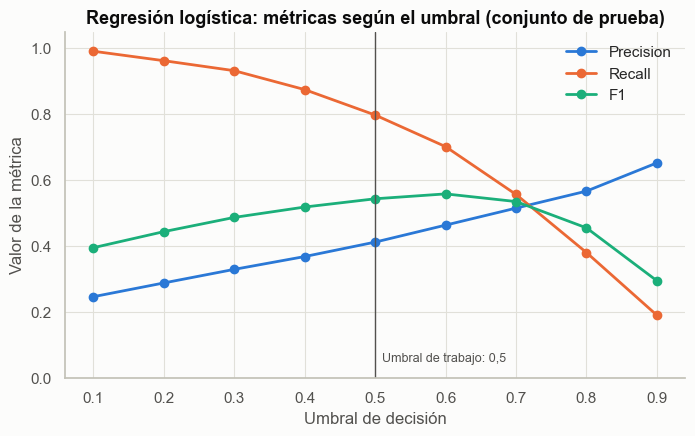

,precision,recall,f1,hogares_priorizados_%
umbral,,,,
0.1,0.247,0.991,0.396,72.645
0.2,0.289,0.962,0.444,60.362
0.3,0.330,0.932,0.487,51.165
0.4,0.369,0.875,0.519,42.961
0.5,0.413,0.798,0.544,35.024
0.6,0.464,0.702,0.559,27.399
0.7,0.516,0.557,0.535,19.567
0.8,0.567,0.381,0.456,12.164
0.9,0.653,0.191,0.295,5.296


In [7]:
prob_final = probabilidades["E2 Regresión logística"]
filas = []
for umbral in np.round(np.arange(0.1, 0.91, 0.1), 1):
    prediccion = (prob_final >= umbral).astype(int)
    filas.append({
        "umbral": umbral,
        "precision": precision_score(y_prueba, prediccion),
        "recall": recall_score(y_prueba, prediccion),
        "f1": f1_score(y_prueba, prediccion),
        "hogares_priorizados_%": prediccion.mean() * 100,
    })
umbrales = pd.DataFrame(filas).set_index("umbral")
umbrales.to_csv("results/tablas/05_analisis_umbral.csv")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(umbrales.index, umbrales["precision"], color=AZUL, linewidth=2, marker="o", label="Precision")
ax.plot(umbrales.index, umbrales["recall"], color=NARANJA, linewidth=2, marker="o", label="Recall")
ax.plot(umbrales.index, umbrales["f1"], color=VERDE_AGUA, linewidth=2, marker="o", label="F1")
ax.axvline(0.5, color=TEXTO_SECUNDARIO, linewidth=1)
ax.text(0.51, 0.05, "Umbral de trabajo: 0,5", color=TEXTO_SECUNDARIO, fontsize=9)
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1.05)
ax.set_title("Regresión logística: métricas según el umbral (conjunto de prueba)")
ax.legend(loc="upper right")
guardar_figura("05_analisis_umbral")
plt.show()

umbrales.round(3)

### Interpretación del umbral

- Con **umbrales bajos** (0,2 a 0,3), el modelo detecta más del 93 % de los hogares pobres, pero prioriza a más de la mitad de todos los hogares y su *precision* no supera 0,33.
- Con **umbrales altos** (0,8 a 0,9), la *precision* sube a 0,57 a 0,65, pero se pierde a la mayoría de los pobres (*recall* ≤ 0,38).
- El F1 alcanza su máximo cerca de **0,6** (0,559), algo por encima del 0,5 (0,544). No se cambia el umbral porque esa observación proviene de la prueba. Queda como **recomendación** calibrarlo con datos de validación en un despliegue real.

**Lectura para la política social.** El umbral no es solo una cuestión técnica: depende del **presupuesto** y de **qué error se considera más grave**.

- Si un programa solo puede atender a alrededor del **20 % de los hogares**, un umbral de 0,7 prioriza al 19,6 % con una *precision* de 0,52.
- Si el objetivo es **no dejar fuera a ningún pobre** y hay presupuesto para cubrir a más hogares, un umbral de 0,3 detecta al 93 % de ellos.

El modelo entrega una **probabilidad**, y esa probabilidad le permite a quien decide elegir el punto de operación con la evidencia de esta tabla.

### 4.1. Cómo leer las probabilidades del modelo

El balanceo de clases (`class_weight="balanced"`) hace que el modelo trate a los hogares pobres como si fueran la mitad de los datos. ¿Sus probabilidades siguen reflejando la frecuencia real de la pobreza?

In [8]:
prob_entrenamiento = modelos["E2 Regresión logística"].predict_proba(X_entrenamiento)[:, 1]
print(f"Probabilidad media que entrega el modelo (entrenamiento): {prob_entrenamiento.mean():.3f}")
print(f"Proporción real de hogares pobres (entrenamiento):        {y_entrenamiento.mean():.3f}")

Probabilidad media que entrega el modelo (entrenamiento): 0.370
Proporción real de hogares pobres (entrenamiento):        0.181


### Interpretación

- Las probabilidades quedan **desplazadas hacia arriba**: la probabilidad media que entrega el modelo (0,37) es aproximadamente el **doble** de la proporción real de hogares pobres (0,18).
- Por eso deben leerse como un **puntaje de riesgo** para ordenar a los hogares y compararlos con el umbral, y **no como la frecuencia exacta de pobreza**. Por ejemplo, un hogar con probabilidad 0,6 tiene más riesgo que uno con 0,4, pero eso no significa que 6 de cada 10 hogares como él sean pobres.
- El balanceo cambia sobre todo el **nivel** de las probabilidades y poco el **orden** de los hogares: el ROC-AUC en prueba es casi el mismo con y sin balanceo (0,853 y 0,851, sección 1).

## 5. Generalización: entrenamiento, validación cruzada y prueba

Comparar el desempeño en entrenamiento con el de prueba permite detectar **sobreajuste** (mucho mejor en entrenamiento que en prueba) o **subajuste** (malo en ambos).

In [9]:
generalizacion = pd.DataFrame({
    nombre: {
        "f1_entrenamiento": f1_score(y_entrenamiento, modelos[nombre].predict(X_entrenamiento)),
        "f1_validacion_cruzada": cv.loc[nombre, "f1_media"],
        "f1_prueba": tabla_prueba.loc[nombre, "f1"],
    } for nombre in ["E2 Regresión logística", "E5 Random Forest", "E3 Árbol de decisión"]
}).T
generalizacion["brecha_entrenamiento_prueba"] = generalizacion["f1_entrenamiento"] - generalizacion["f1_prueba"]
generalizacion.round(3)

,f1_entrenamiento,f1_validacion_cruzada,f1_prueba,brecha_entrenamiento_prueba
E2 Regresión logística,0.558,0.552,0.544,0.014
E5 Random Forest,0.713,0.552,0.549,0.164
E3 Árbol de decisión,0.514,0.500,0.495,0.019


### Interpretación

- **Regresión logística:** F1 de 0,558 en entrenamiento y 0,544 en prueba, una brecha de apenas 0,014. **No hay sobreajuste**: el modelo aprendió relaciones generales, no particularidades de los hogares de entrenamiento.
- **Random Forest:** F1 de 0,713 en entrenamiento y 0,549 en prueba, una brecha de 0,164. **Memoriza parte de los datos de entrenamiento** (sobreajuste), aunque el promedio de sus árboles le permite generalizar tan bien como la regresión logística. Es otra razón para preferir el modelo lineal: su desempeño en entrenamiento es un indicador fiel de su desempeño real.
- **Árbol de decisión:** brecha pequeña (0,019). La profundidad limitada (6) evita el sobreajuste, pero lo deja con menor desempeño general, es decir, con cierto **subajuste**.
- **Hogares vecinos (conglomerados):** la validación cruzada evaluó cada partición con vecinos que el modelo no vio (cuaderno 03, sección 10), mientras que el 99,9 % de los hogares de prueba tiene vecinos en el entrenamiento. Aun así, el F1 es casi igual en ambos casos: 0,552 frente a 0,544 en la regresión logística y 0,552 frente a 0,549 en Random Forest. Si los vecinos inflaran las métricas, la prueba habría salido mejor que la validación cruzada. Como no ocurre, su efecto es pequeño.

## 6. Validación temporal (E6): ¿el modelo sigue funcionando otro año?

Un modelo de focalización se entrena con datos de un año y se aplica en años siguientes. Para simular esa situación:

- se **entrenan** la regresión logística y Random Forest, con los hiperparámetros elegidos en el cuaderno 04, con **todos los hogares de la ENAHO 2024** (33 691);
- se **evalúan** con los **23 860 hogares nuevos de la ENAHO 2025**, excluyendo a los 9 842 hogares del panel que ya fueron entrevistados en 2024 (cuaderno 03).

In [10]:
hogares_2024 = pd.read_csv(RUTA_HOGARES[2024])
panel = pd.read_csv(RUTA_PANEL_2025)
nuevos_2025 = hogares.merge(panel, on=CLAVES_HOGAR)
nuevos_2025 = nuevos_2025[nuevos_2025["es_panel"] == 0]

X_2024, y_2024 = hogares_2024[VARIABLES_PREDICTORAS], hogares_2024[VARIABLE_OBJETIVO]
X_nuevos, y_nuevos = nuevos_2025[VARIABLES_PREDICTORAS], nuevos_2025[VARIABLE_OBJETIVO]
print(f"Entrenamiento ENAHO 2024: {len(X_2024)} hogares ({y_2024.mean() * 100:.1f} % pobres)")
print(f"Evaluación ENAHO 2025 (hogares nuevos): {len(X_nuevos)} hogares ({y_nuevos.mean() * 100:.1f} % pobres)")

# Mismos hiperparámetros elegidos en el cuaderno 04 (E2 y E5), ahora entrenados solo con 2024
logistica_2024 = crear_pipeline(LogisticRegression(C=1, class_weight="balanced", max_iter=3000, random_state=SEMILLA))
bosque_2024 = crear_pipeline(RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=5,
                                                    class_weight="balanced", random_state=SEMILLA, n_jobs=-1))
logistica_2024.fit(X_2024, y_2024)
bosque_2024.fit(X_2024, y_2024)

temporal = {"E0 Regla 'rural = pobre'": calcular_metricas(y_nuevos, regla_rural(X_nuevos))}
for nombre, modelo in [("E2 Regresión logística", logistica_2024), ("E5 Random Forest", bosque_2024)]:
    prob = modelo.predict_proba(X_nuevos)[:, 1]
    temporal[nombre] = calcular_metricas(y_nuevos, (prob >= 0.5).astype(int), prob)

tabla_temporal = pd.DataFrame(temporal).T[["f1", "precision", "recall", "roc_auc", "accuracy"]]
tabla_temporal["f1_prueba_2025"] = tabla_prueba["f1"]
tabla_temporal.to_csv("results/tablas/05_validacion_temporal.csv")
tabla_temporal.round(3)

Entrenamiento ENAHO 2024: 33691 hogares (20.2 % pobres)
Evaluación ENAHO 2025 (hogares nuevos): 23860 hogares (17.7 % pobres)


,f1,precision,recall,roc_auc,accuracy,f1_prueba_2025
E0 Regla 'rural = pobre',0.337,0.258,0.488,NaN,0.661,0.334
E2 Regresión logística,0.544,0.408,0.815,0.861,0.759,0.544
E5 Random Forest,0.555,0.451,0.723,0.857,0.796,0.549


### Interpretación de la validación temporal

- Entrenados con 2024 y evaluados con hogares nuevos de 2025, los modelos **mantienen su desempeño**:
  - regresión logística: F1 = 0,544, *recall* = 0,815 y AUC = 0,861;
  - Random Forest: F1 = 0,555;
  - regla rural: 0,337.
- Son prácticamente los mismos valores obtenidos al entrenar y evaluar dentro de 2025 (0,544 y 0,549).
- Esto ocurre **aunque la pobreza bajó entre ambos años** (de 20,2 % de hogares pobres en la muestra de 2024 a 17,7 % en los hogares nuevos de 2025). Las relaciones entre características observables y pobreza son **estables de un año a otro**.
- Para la aplicación real es un resultado central: **un modelo entrenado con la ENAHO de un año puede usarse para focalizar al año siguiente** sin perder desempeño.

## 7. Interpretabilidad: ¿por qué el modelo decide lo que decide?

### 7.1. Coeficientes de la regresión logística (explicación global)

Cada coeficiente indica cuánto aumenta (+) o disminuye (−) el puntaje de pobreza del hogar (en escala de log-odds). En las variables numéricas, el efecto es por cada desviación estándar; en las binarias y categóricas, es el efecto de tener esa característica. `exp(coeficiente)` indica por cuánto se **multiplica la razón de probabilidades** (odds) de ser pobre.

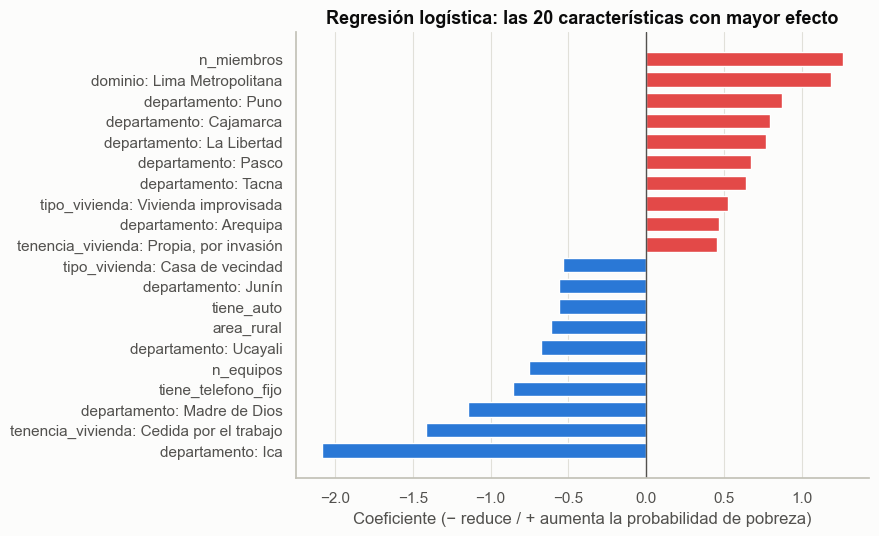

,variable,coeficiente,odds_ratio
0,n_miembros,1.267,3.552
93,dominio: Lima Metropolitana,1.186,3.276
114,departamento: Puno,0.872,2.391
99,departamento: Cajamarca,0.800,2.225
106,departamento: La Libertad,0.768,2.156
112,departamento: Pasco,0.675,1.964
116,departamento: Tacna,0.645,1.907
31,tipo_vivienda: Vivienda improvisada,0.527,1.694
97,departamento: Arequipa,0.471,1.602
59,"tenencia_vivienda: Propia, por invasión",0.459,1.582


In [11]:
modelo_final = modelos["E2 Regresión logística"]
preprocesador = modelo_final.named_steps["preprocesamiento"]
logistica = modelo_final.named_steps["modelo"]

# nombre_legible (src/evaluation/interpretacion.py) convierte 'categoricas__material_piso_6.0' en 'material_piso: Tierra'
coeficientes = pd.DataFrame({
    "variable": [nombre_legible(n) for n in preprocesador.get_feature_names_out()],
    "coeficiente": logistica.coef_[0],
})
coeficientes["odds_ratio"] = np.exp(coeficientes["coeficiente"])
coeficientes["abs"] = coeficientes["coeficiente"].abs()
top = coeficientes.sort_values("abs", ascending=False).head(20).sort_values("coeficiente")
coeficientes.drop(columns="abs").sort_values("coeficiente").to_csv("results/tablas/05_coeficientes_logistica.csv", index=False)

fig, ax = plt.subplots(figsize=(7.4, 5.8))
ax.barh(top["variable"], top["coeficiente"], color=[AZUL if c < 0 else "#e34948" for c in top["coeficiente"]], height=0.7)
ax.axvline(0, color=TEXTO_SECUNDARIO, linewidth=1)
ax.set_xlabel("Coeficiente (− reduce / + aumenta la probabilidad de pobreza)")
ax.set_title("Regresión logística: las 20 características con mayor efecto")
ax.grid(axis="y", visible=False)
guardar_figura("05_coeficientes_logistica")
plt.show()

top.sort_values("coeficiente", ascending=False)[["variable", "coeficiente", "odds_ratio"]].round(3)

### Interpretación de los coeficientes

**Características del hogar que aumentan la probabilidad de pobreza:**

- **Número de miembros** (coeficiente 1,27 por cada desviación estándar, unos 1,7 miembros): con el mismo equipamiento y la misma vivienda, un hogar más grande reparte los recursos entre más personas.
- **Vivienda improvisada** (0,53) y **tenencia por invasión** (0,46): condiciones de vivienda precarias. Fuera del top 20 del gráfico, en la misma dirección, están la vivienda **cedida por otro hogar** (0,45) y el **piso de tierra** (0,38). La tabla completa está en `results/tablas/05_coeficientes_logistica.csv`.

**Características que reducen la probabilidad de pobreza:**

- **Número de artefactos** (−0,75 por desviación estándar), **teléfono fijo** (−0,86), **auto** (−0,56) y **computadora** (−0,39): la tenencia de bienes durables refleja capacidad de gasto acumulada.
- **Vivienda cedida por el centro de trabajo** (−1,42): suele indicar un empleo formal. Es una categoría con pocos hogares (95), así que su coeficiente debe leerse con cautela.

**El efecto de la ubicación requiere una lectura cuidadosa.**

- **Lima Metropolitana** tiene uno de los coeficientes positivos más grandes (1,19), y el **área rural** uno negativo (−0,61). A primera vista parece contradictorio con el cuaderno 02, donde la pobreza rural era mayor.
- La explicación es que el coeficiente mide el efecto **a igualdad de las demás características**. El INEI usa **líneas de pobreza distintas según el costo de vida de cada dominio**: la canasta básica cuesta más en Lima que en el campo. Un hogar con la misma vivienda y los mismos bienes necesita más gasto para no ser pobre en Lima.
- El modelo aprendió esa diferencia: **las mismas condiciones materiales no implican el mismo nivel de vida en todos los lugares**. Lo mismo explica los coeficientes de varios departamentos, como Ica (−2,09) o Puno (+0,87).
- Este punto es importante para la **discusión ética**: la ubicación influye en la predicción, y se debe vigilar que no produzca un trato injusto (sección 8).

### 7.2. Importancia de variables en Random Forest (comparación)

Para contrastar, calculamos la importancia de variables del Random Forest (`feature_importances_`, cuaderno 08 del curso), sumando las columnas One-Hot de cada variable original.

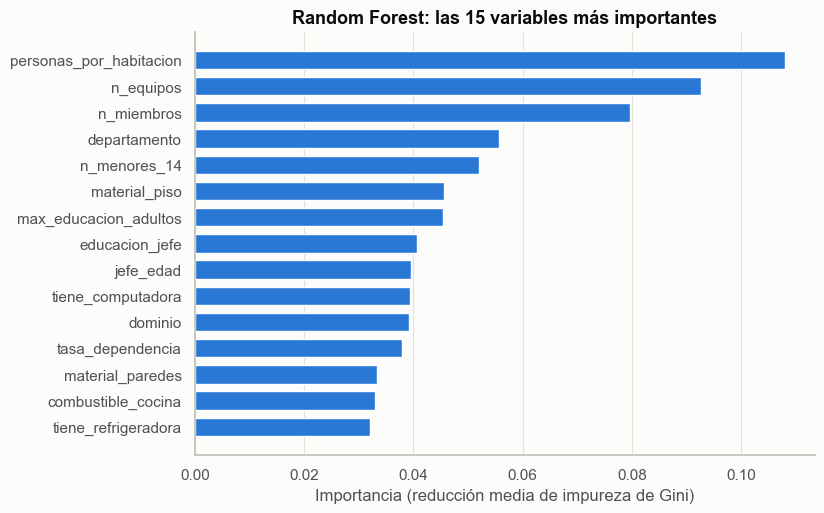

,importancia
personas_por_habitacion,0.108
n_equipos,0.093
n_miembros,0.080
departamento,0.056
n_menores_14,0.052
material_piso,0.046
max_educacion_adultos,0.046
educacion_jefe,0.041
jefe_edad,0.040
tiene_computadora,0.039


In [12]:
bosque = modelos["E5 Random Forest"]
nombres_tecnicos = bosque.named_steps["preprocesamiento"].get_feature_names_out()

# variable_original (src/evaluation/interpretacion.py) convierte 'categoricas__material_piso_6.0' en 'material_piso'
importancia = (pd.Series(bosque.named_steps["modelo"].feature_importances_, index=[variable_original(n) for n in nombres_tecnicos])
               .groupby(level=0).sum().sort_values(ascending=False))
importancia.to_csv("results/tablas/05_importancia_random_forest.csv", header=["importancia"])

top_rf = importancia.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_rf.index, top_rf.values, color=AZUL, height=0.7)
ax.set_xlabel("Importancia (reducción media de impureza de Gini)")
ax.set_title("Random Forest: las 15 variables más importantes")
ax.grid(axis="y", visible=False)
guardar_figura("05_importancia_random_forest")
plt.show()

importancia.head(15).round(3).to_frame("importancia")

### Interpretación de la importancia en Random Forest

- Las variables más importantes son el **hacinamiento** (personas por habitación: 0,108), el **número de artefactos** (0,093), el **número de miembros** (0,080), el **departamento** (0,056) y los **menores de 14 años** (0,052), seguidos de la educación, el material del piso y la tenencia de computadora.
- **Ambos modelos coinciden** en lo esencial: el tamaño y la composición del hogar, la riqueza acumulada en bienes, la vivienda, la educación y la ubicación. Que dos algoritmos tan distintos lleguen a las mismas señales aumenta la confianza en que reflejan **relaciones reales** y no artefactos de un modelo.
- **Limitación:** la importancia por impureza de Gini tiende a favorecer a las variables numéricas con muchos valores posibles. Por eso se usa solo como comparación y no como medida exacta.

### 7.3. Explicación local: un hogar concreto

En la regresión logística, el puntaje de un hogar es la suma de *coeficiente × valor* de cada característica. Por eso se puede calcular de forma **exacta** cuánto aporta cada una a su predicción.

Para que la explicación se lea "frente a algo", comparamos al hogar con el **hogar promedio del entrenamiento**:

$$\text{aporte} = \text{coeficiente} \times (\text{valor del hogar} - \text{valor promedio})$$

- Un **aporte positivo** significa que esa característica hace al hogar **más probablemente pobre** que el hogar promedio.
- Un **aporte negativo**, menos probablemente pobre.
- La suma de todos los aportes es exactamente la diferencia de puntaje entre el hogar y el hogar promedio.

Varias características están **muy relacionadas entre sí** (por ejemplo, el número de miembros, el de menores de 14 y la tasa de dependencia). El modelo reparte su efecto entre ellas, así que el signo de una sola puede confundir. Por eso la explicación principal **suma los aportes por grupos temáticos** (tamaño del hogar, vivienda, bienes, ubicación, etc.), lo que sigue siendo exacto.

Las funciones están en `src/evaluation/interpretacion.py`, y son **las mismas que usa el prototipo**.

In [13]:
# "Hogar promedio": valor medio de cada columna transformada en el entrenamiento
referencia = calcular_referencia(modelo_final, X_entrenamiento)
base = puntaje_referencia(modelo_final, referencia)
print(f"Probabilidad de pobreza del hogar promedio: {1 / (1 + np.exp(-base)):.3f}")

# Hogar representativo: entre los hogares pobres que el modelo prioriza correctamente,
# el de probabilidad más cercana a la mediana de ese grupo
detectados = np.where((y_prueba == 1) & (prob_final >= 0.5))[0]
indice = int(detectados[np.argmin(np.abs(prob_final[detectados] - np.median(prob_final[detectados])))])
hogar = X_prueba.iloc[[indice]]
explicacion = explicar_hogar(modelo_final, hogar, referencia)

# Comprobación: puntaje del hogar = puntaje del hogar promedio + suma de los aportes
puntaje_hogar = np.log(prob_final[indice] / (1 - prob_final[indice]))
print(f"Comprobación de la suma de aportes: {np.isclose(puntaje_hogar, base + explicacion['aporte'].sum())}")

print(f"\nProbabilidad estimada para el hogar: {prob_final[indice]:.3f} | Condición real (INEI): {'Pobre' if y_prueba.iloc[indice] == 1 else 'No pobre'}")
print("\nAporte de cada grupo de características (+ eleva / − reduce la probabilidad):")
print(resumir_por_grupo(explicacion).round(3).to_string())

# Detalle: las 6 características que más elevan la probabilidad y las 3 que más la reducen
pd.concat([explicacion.head(6), explicacion.tail(3)])[["grupo", "nombre", "valor", "aporte"]].round(3)

Probabilidad de pobreza del hogar promedio: 0.267
Comprobación de la suma de aportes: True

Probabilidad estimada para el hogar: 0.789 | Condición real (INEI): Pobre

Aporte de cada grupo de características (+ eleva / − reduce la probabilidad):
grupo
Ubicación                                1.484
Artefactos y vehículos                   1.435
Hacinamiento                             0.403
Educación                                0.237
Comunicaciones                           0.198
Vivienda: tipo, materiales y tenencia    0.130
Jefe(a) del hogar                        0.014
Servicios básicos                       -0.133
Tamaño y composición del hogar          -1.443


,grupo,nombre,valor,aporte
0,Ubicación,Dominio geográfico,Lima Metropolitana,1.216
1,Artefactos y vehículos,Artefactos y vehículos,1,1.003
2,Hacinamiento,Habitaciones,1,0.404
3,Comunicaciones,Celular,No,0.353
4,Educación,Mayor educación entre los adultos,Secundaria incompleta,0.220
5,Ubicación,Área rural,No,0.210
33,Comunicaciones,TV por cable,Sí,-0.200
34,"Vivienda: tipo, materiales y tenencia",Techo,Concreto armado,-0.220
35,Tamaño y composición del hogar,Miembros del hogar,1,-1.598


### Interpretación de la explicación local

- El hogar elegido es **representativo** de los hogares pobres que el modelo detecta: su probabilidad (0,789) es la mediana de ese grupo. Es un hogar de **una sola persona de 71 años en Lima Metropolitana**, con un solo artefacto (TV a color), sin celular, en una vivienda de adobe cedida por otro hogar.
- Lo que más **eleva** su probabilidad es la **ubicación** (+1,48), porque en Lima Metropolitana la línea de pobreza es más alta (sección 7.1), y la **falta de artefactos y vehículos** (+1,44): solo tiene uno, frente a 5 o 6 del hogar promedio.
- Lo que más la **reduce** es el **tamaño del hogar** (−1,44). Con un solo miembro, el gasto necesario para no ser pobre es menor que en un hogar de 3 o 4 personas.
- En el detalle, cada característica aparece con su valor real. Por ejemplo, "Celular: No" eleva la probabilidad (+0,35) y "Techo: Concreto armado" la reduce (−0,22).

Este tipo de explicación es la que el prototipo muestra para cada hogar evaluado. Así, la decisión de priorizarlo **no es una caja negra**: puede justificarse ante el hogar, el funcionario y un eventual reclamo.

## 8. Análisis de sesgo: ¿el modelo se equivoca más con algunos grupos?

Un modelo de focalización puede ser bueno en promedio y, aun así, **dejar fuera sistemáticamente a ciertos grupos**. Evaluamos el *recall* (qué proporción de los pobres de cada grupo detecta), la *precision* y el F1 por **área**, **dominio geográfico** y **sexo del jefe(a) del hogar**, con los dos mejores modelos.

In [14]:
evaluacion = prueba.assign(
    pred_logistica=(probabilidades["E2 Regresión logística"] >= 0.5).astype(int),
    pred_bosque=(probabilidades["E5 Random Forest"] >= 0.5).astype(int),
    area=prueba["area_rural"].map({0: "Urbano", 1: "Rural"}),
    sexo_jefe=prueba["jefe_mujer"].map({0: "Jefe hombre", 1: "Jefa mujer"}),
    dominio_nombre=prueba["dominio"].map(ETIQUETAS["dominio"]),
)


def metricas_por_grupo(columna):
    filas = []
    for grupo, datos in evaluacion.groupby(columna):
        filas.append({
            "grupo": grupo,
            "hogares": len(datos),
            "hogares_pobres": int(datos[VARIABLE_OBJETIVO].sum()),
            "recall_logistica": recall_score(datos[VARIABLE_OBJETIVO], datos["pred_logistica"]),
            "precision_logistica": precision_score(datos[VARIABLE_OBJETIVO], datos["pred_logistica"], zero_division=0),
            "f1_logistica": f1_score(datos[VARIABLE_OBJETIVO], datos["pred_logistica"]),
            "recall_bosque": recall_score(datos[VARIABLE_OBJETIVO], datos["pred_bosque"]),
        })
    return pd.DataFrame(filas).set_index("grupo")


sesgo = {"Área": metricas_por_grupo("area"), "Sexo del jefe(a)": metricas_por_grupo("sexo_jefe"),
         "Dominio": metricas_por_grupo("dominio_nombre")}
pd.concat(sesgo).to_csv("results/tablas/05_analisis_sesgo.csv")

for titulo, tabla in sesgo.items():
    print(f"\n{titulo}")
    display(tabla.round(3))


Área


,hogares,hogares_pobres,recall_logistica,precision_logistica,f1_logistica,recall_bosque
grupo,,,,,,
Rural,2314,591,0.875,0.415,0.563,0.826
Urbano,4427,630,0.725,0.409,0.523,0.565



Sexo del jefe(a)


,hogares,hogares_pobres,recall_logistica,precision_logistica,f1_logistica,recall_bosque
grupo,,,,,,
Jefa mujer,2481,419,0.733,0.389,0.508,0.640
Jefe hombre,4260,802,0.832,0.424,0.562,0.718



Dominio


,hogares,hogares_pobres,recall_logistica,precision_logistica,f1_logistica,recall_bosque
grupo,,,,,,
Costa Centro,679,59,0.593,0.347,0.438,0.458
Costa Norte,983,162,0.698,0.440,0.539,0.568
Costa Sur,464,42,0.548,0.261,0.354,0.333
Lima Metropolitana,798,144,0.778,0.446,0.567,0.562
Selva,1420,264,0.784,0.418,0.545,0.739
Sierra Centro,1095,258,0.868,0.406,0.553,0.771
Sierra Norte,387,128,0.906,0.455,0.606,0.867
Sierra Sur,915,164,0.878,0.398,0.548,0.762


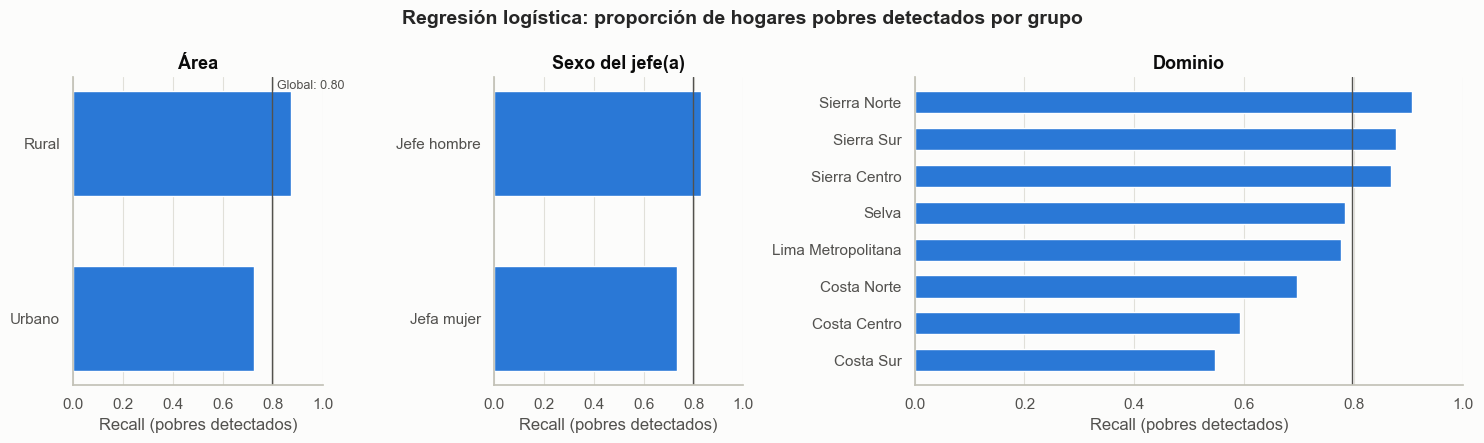

In [15]:
recall_global = recall_score(y_prueba, evaluacion["pred_logistica"])
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 1, 2.2]})
for ax, (titulo, tabla) in zip(ejes, sesgo.items()):
    tabla = tabla.sort_values("recall_logistica")
    ax.barh(tabla.index, tabla["recall_logistica"], color=AZUL, height=0.6)
    ax.axvline(recall_global, color=TEXTO_SECUNDARIO, linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_title(titulo)
    ax.set_xlabel("Recall (pobres detectados)")
    ax.grid(axis="y", visible=False)
ejes[0].text(recall_global + 0.02, 0.99, f"Global: {recall_global:.2f}", color=TEXTO_SECUNDARIO, fontsize=9,
             va="top", transform=ejes[0].get_xaxis_transform())
fig.suptitle("Regresión logística: proporción de hogares pobres detectados por grupo", fontsize=14, fontweight="bold")
fig.tight_layout()
guardar_figura("05_sesgo_recall_grupos")
plt.show()

### Interpretación del análisis de sesgo

**Área urbana y rural.**

- El modelo detecta al **87,5 % de los hogares pobres rurales**, pero solo al **72,5 % de los urbanos**. Es decir, deja fuera a más del doble de pobres urbanos (27,5 %) que rurales (12,5 %).
- Esto es relevante porque, como se vio en el cuaderno 02, **el 74 % de las personas pobres vive en zonas urbanas**.
- La pobreza urbana es más difícil de detectar con características de vivienda: un hogar urbano pobre suele tener piso de cemento, agua de red y celular, igual que uno no pobre.

**Sexo del jefe(a) del hogar.**

- Los hogares pobres con **jefa mujer** se detectan menos (73,3 %) que los de **jefe hombre** (83,2 %).
- Es una **brecha de equidad** que debe explicitarse: si el modelo se usara tal cual, los hogares pobres encabezados por mujeres tendrían más probabilidad de quedar fuera de los programas.

**Dominio geográfico.**

- El *recall* va de **90,6 % en la Sierra Norte** a **54,8 % en la Costa Sur** y **59,3 % en la Costa Centro**. Las regiones con menor pobreza (costa) tienen más errores de exclusión, porque ahí los pobres se parecen más a los no pobres.
- En **Lima Metropolitana** el *recall* es de 77,8 % y el F1, de 0,567, cercanos al promedio.
- En la Costa Sur solo hay 42 hogares pobres en la prueba, así que su estimación es menos precisa.

**Ambos modelos muestran el mismo patrón** (columna `recall_bosque`). Las brechas provienen de la **información disponible** (características observables) y no de un algoritmo en particular.

**Implicación:** estas brechas no invalidan el modelo, pero obligan a **no usarlo como único criterio**. Se discutirán en las consideraciones éticas, con recomendaciones como umbrales diferenciados o verificación adicional en zonas urbanas y en hogares con jefa mujer.

## 9. Evaluación del modelo como artefacto

Un modelo útil no solo debe acertar: debe poder **usarse** dentro de un sistema. Medimos el tiempo de respuesta, el tamaño y la robustez ante datos incompletos.

In [16]:
un_hogar = X_prueba.iloc[[0]]

inicio = time.perf_counter()
for _ in range(100):
    modelo_final.predict_proba(un_hogar)
tiempo_un_hogar = (time.perf_counter() - inicio) / 100 * 1000

inicio = time.perf_counter()
modelo_final.predict_proba(X_prueba)
tiempo_lote = time.perf_counter() - inicio

inicio = time.perf_counter()
for _ in range(20):
    bosque.predict_proba(un_hogar)
tiempo_bosque = (time.perf_counter() - inicio) / 20 * 1000

# Robustez: un hogar con varias respuestas faltantes
hogar_incompleto = un_hogar.copy()
hogar_incompleto[["n_habitaciones", "material_piso", "tiene_refrigeradora", "educacion_jefe"]] = np.nan
prob_incompleto = modelo_final.predict_proba(hogar_incompleto)[0, 1]

artefacto = pd.DataFrame({
    "Regresión logística (E2)": {
        "tiempo_1_hogar_ms": tiempo_un_hogar,
        "tiempo_6741_hogares_s": tiempo_lote,
        "tamano_archivo_MB": os.path.getsize(os.path.join(CARPETA_MODELOS, archivos["E2 Regresión logística"])) / 1e6,
    },
    "Random Forest (E5)": {
        "tiempo_1_hogar_ms": tiempo_bosque,
        "tiempo_6741_hogares_s": np.nan,
        "tamano_archivo_MB": os.path.getsize(os.path.join(CARPETA_MODELOS, archivos["E5 Random Forest"])) / 1e6,
    },
}).T
print(f"Probabilidad para un hogar con 4 respuestas faltantes: {prob_incompleto:.3f} (el pipeline imputa y responde sin errores)")
artefacto.round(3)

Probabilidad para un hogar con 4 respuestas faltantes: 0.128 (el pipeline imputa y responde sin errores)


,tiempo_1_hogar_ms,tiempo_6741_hogares_s,tamano_archivo_MB
Regresión logística (E2),4.262,0.01,0.009
Random Forest (E5),31.559,NaN,62.973


### Interpretación

- La regresión logística responde en **pocos milisegundos por hogar** y evalúa a los 6 741 hogares de prueba en una fracción de segundo. El archivo del modelo ocupa **menos de 10 KB**.
- Random Forest es **varias veces más lento** por hogar (ver la tabla) y su archivo pesa **más de 60 MB**.
- El pipeline **tolera respuestas faltantes**: un hogar con cuatro datos vacíos recibe una probabilidad sin errores, gracias a la imputación aprendida en el entrenamiento.
- Estas propiedades hacen que la regresión logística sea **adecuada para un prototipo** que responde de inmediato, e incluso para evaluar a miles de hogares a la vez.

## 10. Selección final del modelo

| Criterio | Regresión logística (E2) | Random Forest (E5) | Favorece a |
|---|---|---|---|
| F1 validación cruzada | 0,552 ± 0,010 | 0,552 ± 0,014 | Empate |
| F1 prueba | 0,544 | 0,549 | Empate (diferencia < desviación) |
| F1 validación temporal 2024 → 2025 | 0,544 | 0,555 | Empate (diferencia < desviación) |
| Recall en prueba (menos exclusión) | **0,798** | 0,691 | Regresión logística |
| Precision en prueba (menos filtración) | 0,413 | **0,455** | Random Forest |
| ROC-AUC en prueba | **0,853** | 0,849 | Regresión logística |
| Sobreajuste (brecha entrenamiento-prueba) | **0,014** | 0,164 | Regresión logística |
| Interpretabilidad | **Coeficientes y explicación por hogar** | Importancia global aproximada | Regresión logística |
| Tiempo de respuesta y tamaño | **milisegundos / 9 KB** | varias veces más lento / 63 MB | Regresión logística |

**Modelo final: regresión logística con `C=1` y `class_weight="balanced"` (E2), con umbral de 0,5.**

En desempeño global, ambos modelos son equivalentes. Siguiendo la regla de selección definida antes de los experimentos, se elige el **más interpretable**. Además, deja fuera a menos hogares pobres, no sobreajusta y es más eficiente. Random Forest queda documentado como alternativa con un equilibrio distinto de errores, porque incluye a menos hogares no pobres.

### Guardado del modelo final para el prototipo

In [17]:
ruta_final = os.path.join(CARPETA_MODELOS, "modelo_final.joblib")
joblib.dump(modelo_final, ruta_final)

metadatos = {
    "modelo": "Regresión logística (E2)",
    "hiperparametros": {"C": 1, "class_weight": "balanced", "max_iter": 3000, "random_state": SEMILLA},
    "umbral_decision": 0.5,
    "variables_predictoras": VARIABLES_PREDICTORAS,
    # "Hogar promedio" del entrenamiento: base de la explicación de cada predicción en el prototipo
    "referencia_explicacion": {nombre: float(valor) for nombre, valor in referencia.items()},
    "datos_entrenamiento": "ENAHO 2025 (INEI), 26 961 hogares de entrenamiento",
    "metricas_prueba": {k: round(float(v), 4) for k, v in tabla_prueba.loc["E2 Regresión logística", ["f1", "precision", "recall", "roc_auc", "accuracy"]].items()},
    "metricas_validacion_temporal": {k: round(float(v), 4) for k, v in tabla_temporal.loc["E2 Regresión logística", ["f1", "precision", "recall", "roc_auc", "accuracy"]].items()},
    "version_scikit_learn": sklearn.__version__,
    "fecha": "2026-09-24",
}
with open(os.path.join(CARPETA_MODELOS, "modelo_final_metadatos.json"), "w", encoding="utf-8") as archivo:
    json.dump(metadatos, archivo, ensure_ascii=False, indent=2)

print("Modelo final guardado en:", ruta_final)
print(json.dumps(metadatos["metricas_prueba"], indent=2))

Modelo final guardado en: models\modelo_final.joblib
{
  "f1": 0.5438,
  "precision": 0.4125,
  "recall": 0.7977,
  "roc_auc": 0.8526,
  "accuracy": 0.7576
}


## Conclusiones del cuaderno

**Respecto al OE4 (evaluación experimental).**

- En el conjunto de prueba, nunca usado antes, el modelo seleccionado obtiene **F1 = 0,544, recall = 0,798, precision = 0,413 y ROC-AUC = 0,853**, valores coherentes con la validación cruzada.
- Frente a la regla rural (F1 = 0,334), **detecta 383 hogares pobres más y comete 336 errores de inclusión menos**: mejora en los dos tipos de error.
- La **validación temporal** (entrenar con 2024 y evaluar con hogares nuevos de 2025) confirma que el desempeño se mantiene de un año a otro (F1 = 0,544).

**Respecto al OE5 (comparación y selección).**

- Regresión logística y Random Forest son **equivalentes en desempeño global**. Se selecciona la **regresión logística** por la regla definida de antemano (interpretabilidad), y además tiene menos errores de exclusión, no sobreajusta y es más eficiente.

**Hallazgos para la discusión.**

1. Las predicciones se basan en señales coherentes y compartidas por ambos modelos: tamaño y composición del hogar, bienes durables, vivienda, educación y ubicación. Esta última refleja diferencias en el costo de vida.
2. El umbral de decisión permite adaptar el modelo al presupuesto de un programa. El modelo entrega probabilidades, no solo etiquetas.
3. Existen **brechas de equidad**: más errores de exclusión en hogares urbanos, en hogares con jefa mujer y en la costa. Deben considerarse en el uso responsable del modelo.

## Resumen de los cinco cuadernos

| Cuaderno | Resultado principal |
|---|---|
| 01 · Comprensión de los datos | Los microdatos reproducen exactamente la pobreza oficial del INEI (25,7 % en 2025 y 27,6 % en 2024). El dataset tiene 33 702 hogares y 36 variables observables, sin ingresos ni gastos |
| 02 · Análisis exploratorio | Ninguna característica aislada separa a pobres de no pobres, y la mitad de los hogares pobres de la muestra es urbana: la regla «rural = pobre» no basta |
| 03 · Preparación | Partición estratificada 80/20, preprocesamiento dentro del pipeline y validación temporal sin hogares repetidos: no hay fuga de información |
| 04 · Modelado | La regresión logística balanceada y Random Forest empatan en validación cruzada (F1 = 0,552, frente a 0,347 de la regla). Se elige la regresión logística por ser más interpretable |
| 05 · Evaluación | En la prueba, F1 = 0,544 frente a 0,334 de la regla, con menos errores de exclusión y de inclusión. El desempeño se mantiene de 2024 a 2025, y hay brechas en hogares urbanos, costeros y con jefa mujer |

**Después de los cuadernos.** El prototipo (`app/app.py`) carga `models/modelo_final.joblib`: recibe las características de un hogar y devuelve su probabilidad de pobreza con la explicación de la sección 7.3, calculada con las mismas funciones. El prototipo y sus pruebas se describen en el README y en el informe.